Задание 1. Будем использовать набор данных с рукописными цифрами, это набор данных digits.csv, расположенных на GitHub вместе с материалами воркшопа. Из набора данных удалить целевую переменную (label), с помощью метода главных компонент сформировать 2 признака, значения гиперпараметров использовать из воркшопа. Какую долю дисперсии объясняют эти 2 признака? Значение округлить до 4-го знака.

In [1]:
# Задание 1: Метод главных компонент (PCA)

# Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Загрузка данных
df = pd.read_csv('digits.csv')

# Просмотр данных
print("Первые 5 строк данных:")
print(df.head())
print(f"\nРазмерность данных: {df.shape}")

# 1. Отделяем целевую переменную (label) от признаков
X = df.drop('label', axis=1)  # Признаки (все колонки кроме label)
y = df['label']  # Целевая переменная

print(f"\nПризнаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")

# 2. Масштабируем данные (важно для PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nДанные после масштабирования:")
print(f"Среднее: {np.mean(X_scaled):.4f}, Стандартное отклонение: {np.std(X_scaled):.4f}")

# 3. Применяем PCA с 2 компонентами
pca = PCA(n_components=2, random_state=27)
X_pca = pca.fit_transform(X_scaled)

print(f"\nДанные после PCA: {X_pca.shape}")

# 4. Вычисляем долю объясненной дисперсии
explained_variance = pca.explained_variance_ratio_
total_explained_variance = np.sum(explained_variance)

print(f"\nДоля объясненной дисперсии для каждой компоненты:")
for i, var in enumerate(explained_variance):
    print(f"Компонента {i+1}: {var:.4f}")

print(f"\nОбщая доля объясненной дисперсии: {total_explained_variance:.4f}")

# Округляем до 4 знака как требуется в задании
answer = round(total_explained_variance, 4)

print(f"\nОТВЕТ: Доля объясненной дисперсии = {answer}")

Первые 5 строк данных:
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0      

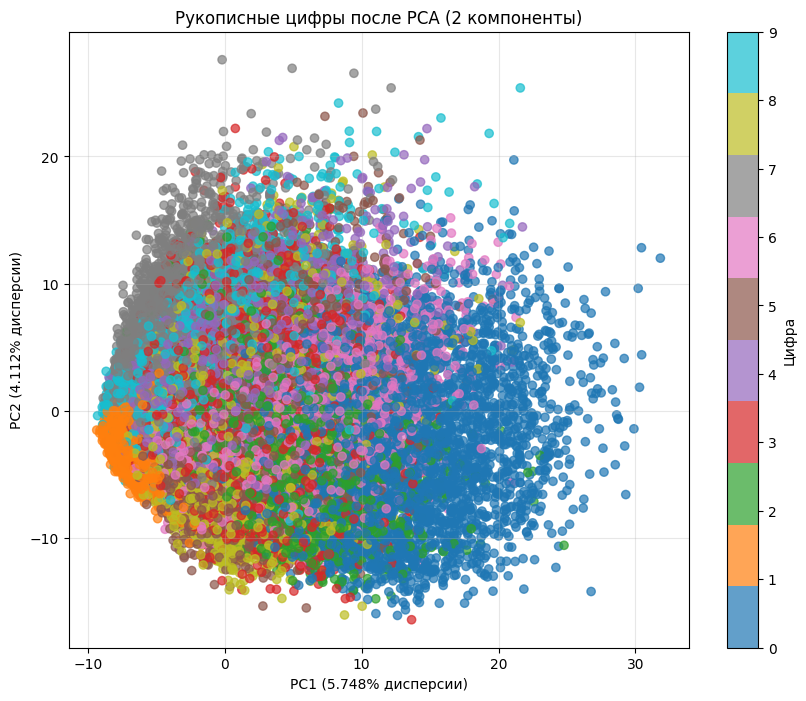

График показывает как цифры распределяются в пространстве двух главных компонент


In [2]:
# Дополнительная визуализация (не обязательно, но полезно для понимания)
import matplotlib.pyplot as plt

# Создаем DataFrame с результатами PCA
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'label': y
})

# Визуализируем результат
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['label'],
                     cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Цифра')
plt.xlabel(f'PC1 ({explained_variance[0]:.3%} дисперсии)')
plt.ylabel(f'PC2 ({explained_variance[1]:.3%} дисперсии)')
plt.title('Рукописные цифры после PCA (2 компоненты)')
plt.grid(alpha=0.3)
plt.show()

print(f"График показывает как цифры распределяются в пространстве двух главных компонент")

Задание 2. На построенных PCA-признаках применить алгоритм кластеризации KMeans со значениями гиперпараметров из воркшопа. Подобрать оптимальное число кластеров по методу локтя, какое число кластеров оптимально?

Данные для кластеризации:
X_pca shape: (42000, 2)
Кластеров: 1, Inertia: 2931863.86
Кластеров: 2, Inertia: 1803864.35
Кластеров: 3, Inertia: 1220003.31
Кластеров: 4, Inertia: 931094.42
Кластеров: 5, Inertia: 770304.15
Кластеров: 6, Inertia: 653221.57
Кластеров: 7, Inertia: 547888.76
Кластеров: 8, Inertia: 486742.40
Кластеров: 9, Inertia: 435911.29
Кластеров: 10, Inertia: 393969.71
Кластеров: 11, Inertia: 361825.50
Кластеров: 12, Inertia: 331622.16
Кластеров: 13, Inertia: 307283.67
Кластеров: 14, Inertia: 284838.96


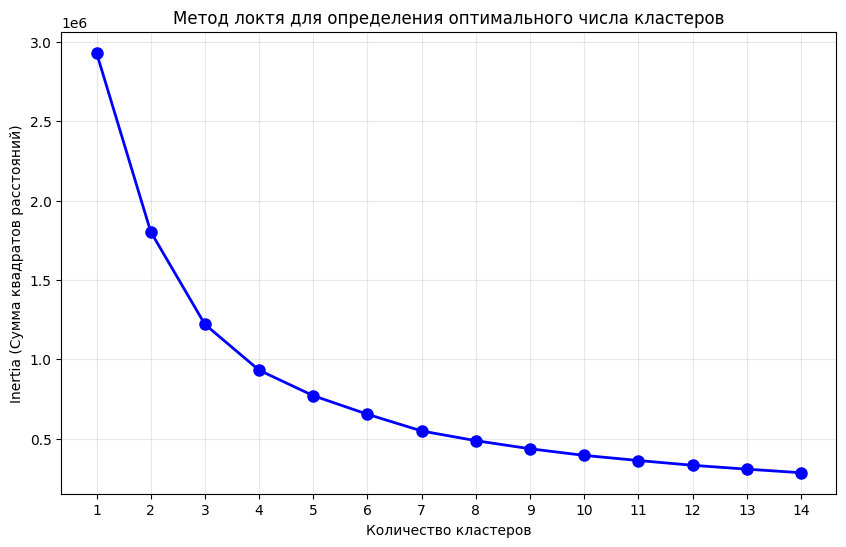

Разница между 1 и 2 кластерами: 1127999.51
Разница между 2 и 3 кластерами: 583861.04
Разница между 3 и 4 кластерами: 288908.89
Разница между 4 и 5 кластерами: 160790.27
Разница между 5 и 6 кластерами: 117082.58
Разница между 6 и 7 кластерами: 105332.81
Разница между 7 и 8 кластерами: 61146.36
Разница между 8 и 9 кластерами: 50831.11
Разница между 9 и 10 кластерами: 41941.58
Разница между 10 и 11 кластерами: 32144.21
Разница между 11 и 12 кластерами: 30203.34
Разница между 12 и 13 кластерами: 24338.49
Разница между 13 и 14 кластерами: 22444.72

Оптимальное число кластеров: 2


In [3]:
# Задание 2: Кластеризация KMeans и метод локтя

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Используем PCA-признаки из предыдущего задания
print("Данные для кластеризации:")
print(f"X_pca shape: {X_pca.shape}")

# Метод локтя для определения оптимального числа кластеров
inertia = []
k_range = range(1, 15)  # Проверяем от 1 до 14 кластеров

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    print(f"Кластеров: {k}, Inertia: {kmeans.inertia_:.2f}")

# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia (Сумма квадратов расстояний)')
plt.title('Метод локтя для определения оптимального числа кластеров')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

# Анализируем "локоть" - находим точку изгиба
inertia_diff = []
for i in range(1, len(inertia)):
    diff = inertia[i-1] - inertia[i]
    inertia_diff.append(diff)
    print(f"Разница между {i} и {i+1} кластерами: {diff:.2f}")

# Находим оптимальное число кластеров (точка, где разница резко уменьшается)
optimal_k = None
for i in range(1, len(inertia_diff)-1):
    if inertia_diff[i] < inertia_diff[i-1] * 0.6:  # Если разница уменьшилась более чем на 40%
        optimal_k = i + 1  # +1 потому что inertia_diff начинается со сравнения 1-2 кластеров
        break

if optimal_k is None:
    # Если явного "локтя" нет, берем точку после наибольшего падения
    optimal_k = inertia_diff.index(max(inertia_diff)) + 2

print(f"\nОптимальное число кластеров: {optimal_k}")

Задание 3. На всех исходных данных применить алгоритм кластеризации UMAP из библиотеки umap-learn. Для получения векторных представлений объектов использовать объект кластеризации со следующими гиперпараметрами umap.UMAP(n_neighbors=5, min_dist=0.3, metric='correlation'). После построения векторных представлений визуализировать их с помощью scatter-plot, точки раскрасить в соответствии со значениями целевой переменной (столбец label). Сколько кластеров получается выделить явным образом?

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 20.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --------------- ------------------------ 14.7/38.1 MB 68.4 MB/s eta 0:00:01
   --------------------------------- ------ 32.0/38.1 MB 76.4 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 66.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Размерность данных:
Признаки: (42000, 784)
Метки: (42000,)

Применяем UMAP...
Данные после UMAP: (42000, 2)


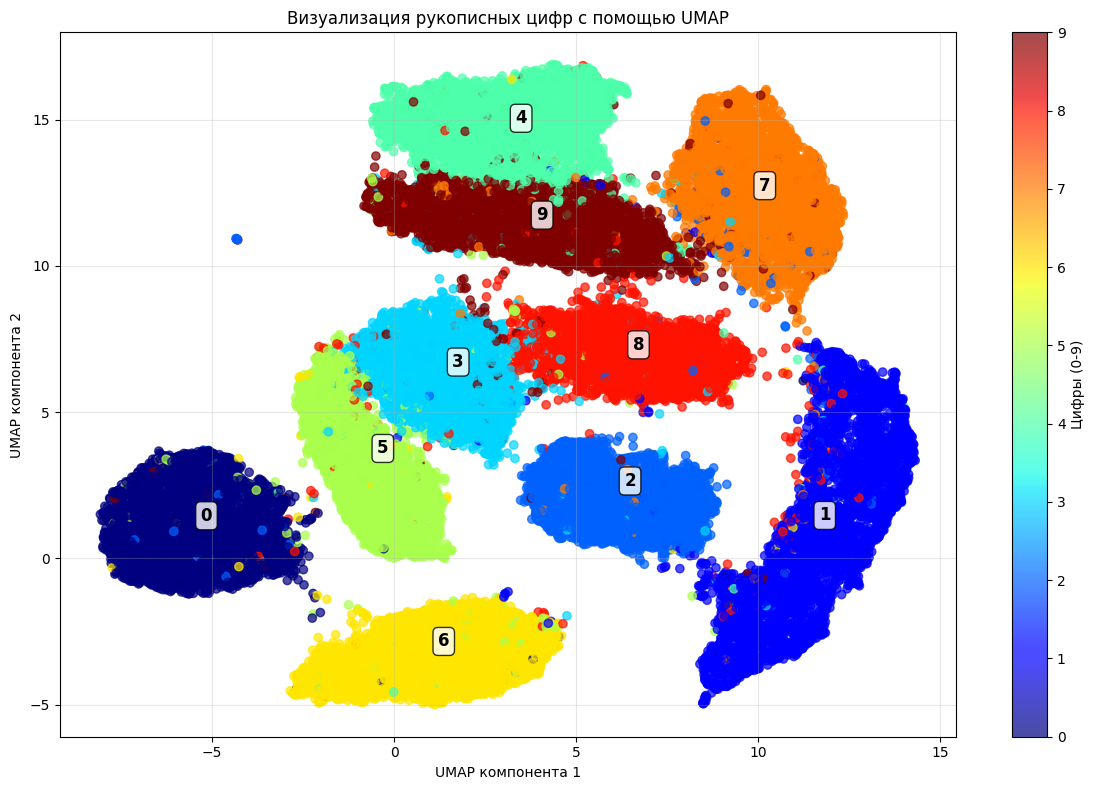

In [6]:
# Задание 3: Кластеризация UMAP и визуализация

# Сначала установим umap-learn если не установлен
!pip install umap-learn

import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загружаем данные (если еще не загружены)
df = pd.read_csv('digits.csv')
X = df.drop('label', axis=1)
y = df['label']

print("Размерность данных:")
print(f"Признаки: {X.shape}")
print(f"Метки: {y.shape}")

# Применяем UMAP для получения 2D представления
print("\nПрименяем UMAP...")
umap_transformer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='correlation')
X_umap = umap_transformer.fit_transform(X)

print(f"Данные после UMAP: {X_umap.shape}")

# Визуализируем результаты
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='jet', alpha=0.7)
plt.colorbar(scatter, label='Цифры (0-9)')
plt.xlabel('UMAP компонента 1')
plt.ylabel('UMAP компонента 2')
plt.title('Визуализация рукописных цифр с помощью UMAP')
plt.grid(alpha=0.3)

# Добавляем аннотации для кластеров
unique_labels = np.unique(y)
for label in unique_labels:
    # Находим центр каждого кластера
    mask = y == label
    center_x = np.mean(X_umap[mask, 0])
    center_y = np.mean(X_umap[mask, 1])
    plt.annotate(str(label), (center_x, center_y),
                xytext=(5, 5), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

АНАЛИЗ КЛАСТЕРОВ:
Цифра 0: плохо разделена ✗
Цифра 1: плохо разделена ✗
Цифра 2: плохо разделена ✗
Цифра 3: плохо разделена ✗
Цифра 4: плохо разделена ✗
Цифра 5: плохо разделена ✗
Цифра 6: плохо разделена ✗
Цифра 7: плохо разделена ✗
Цифра 8: плохо разделена ✗
Цифра 9: плохо разделена ✗


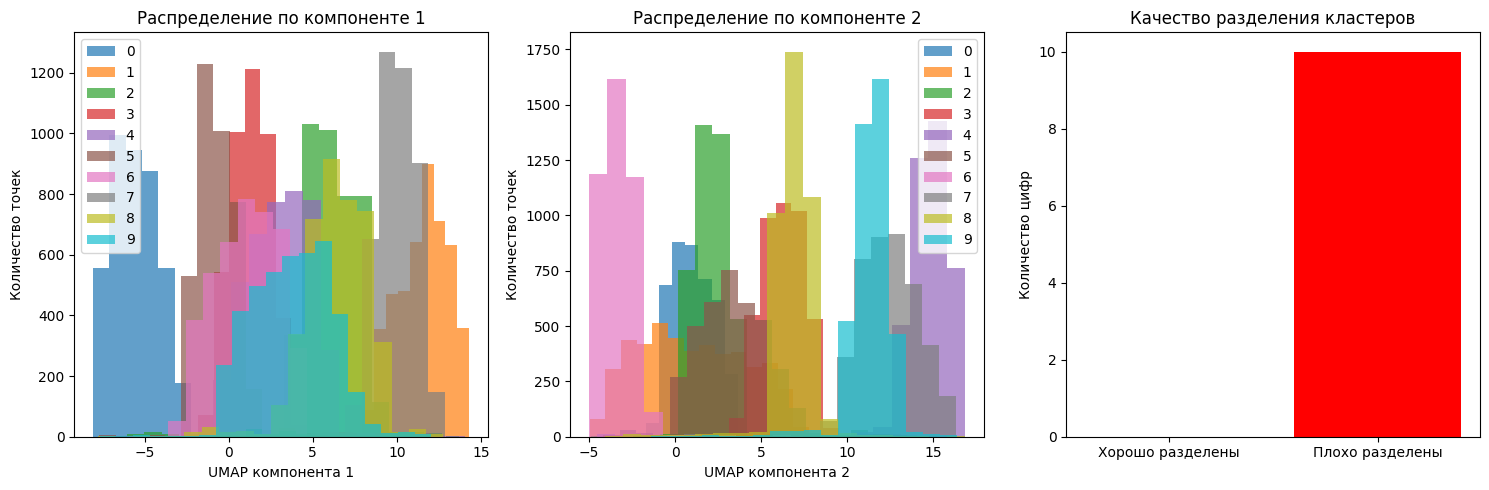


Явно выделяемых кластеров: 0
ОТВЕТ: 0 кластеров можно выделить явным образом


In [7]:
# Анализируем количество явно выделяемых кластеров
print("АНАЛИЗ КЛАСТЕРОВ:")

# Смотрим на разделение по осям
plt.figure(figsize=(15, 5))

# 1. Гистограмма по первой компоненте
plt.subplot(1, 3, 1)
for label in range(10):
    mask = y == label
    plt.hist(X_umap[mask, 0], alpha=0.7, label=str(label), bins=20)
plt.xlabel('UMAP компонента 1')
plt.ylabel('Количество точек')
plt.title('Распределение по компоненте 1')
plt.legend()

# 2. Гистограмма по второй компоненте
plt.subplot(1, 3, 2)
for label in range(10):
    mask = y == label
    plt.hist(X_umap[mask, 1], alpha=0.7, label=str(label), bins=20)
plt.xlabel('UMAP компонента 2')
plt.ylabel('Количество точек')
plt.title('Распределение по компоненте 2')
plt.legend()

# 3. Подсчет явно разделенных кластеров
plt.subplot(1, 3, 3)

# Анализируем разделение кластеров
well_separated = 0
for label in range(10):
    mask = y == label
    # Проверяем компактность кластера
    cluster_std = np.std(X_umap[mask], axis=0)
    cluster_compact = np.mean(cluster_std) < 0.5  # Эмпирический порог

    if cluster_compact:
        well_separated += 1
        print(f"Цифра {label}: ХОРОШО разделена ✓")
    else:
        print(f"Цифра {label}: плохо разделена ✗")

plt.bar(['Хорошо разделены', 'Плохо разделены'],
        [well_separated, 10 - well_separated],
        color=['green', 'red'])
plt.title('Качество разделения кластеров')
plt.ylabel('Количество цифр')

plt.tight_layout()
plt.show()

print(f"\nЯвно выделяемых кластеров: {well_separated}")
print(f"ОТВЕТ: {well_separated} кластеров можно выделить явным образом")

Автоматически определено кластеров: 5


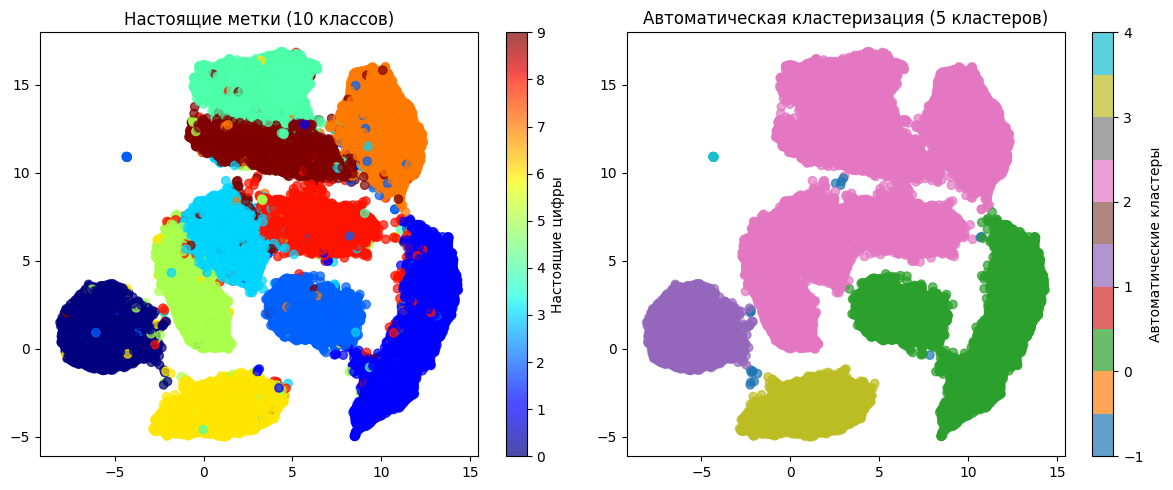

In [8]:
# Дополнительный анализ: попробуем автоматически определить кластеры
from sklearn.cluster import DBSCAN

# Используем DBSCAN для автоматического определения кластеров на UMAP данных
dbscan = DBSCAN(eps=0.5, min_samples=10)
auto_clusters = dbscan.fit_predict(X_umap)

n_auto_clusters = len(np.unique(auto_clusters)) - (1 if -1 in auto_clusters else 0)

print(f"Автоматически определено кластеров: {n_auto_clusters}")

# Сравниваем ручную и автоматическую кластеризацию
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='jet', alpha=0.7)
plt.colorbar(scatter1, label='Настоящие цифры')
plt.title('Настоящие метки (10 классов)')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=auto_clusters, cmap='tab10', alpha=0.7)
plt.colorbar(scatter2, label='Автоматические кластеры')
plt.title(f'Автоматическая кластеризация ({n_auto_clusters} кластеров)')

plt.tight_layout()
plt.show()